# Project 11

Compare a parameter-efficient LoRA fine-tune of `roberta-base` against a plain
linear-probe baseline on the SST-2 sentiment task.

## Setup

In [ ]:
%pip install -q "transformers>=4.40" "datasets>=2.19" "peft>=0.11" "accelerate>=0.30" scikit-learn
# torchao 0.10 that comes with colab caused problems, so I dropped it
%pip uninstall -q -y torchao

In [ ]:
import time, json
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import torch

# for visualising results
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import(
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed,
)
from peft import LoraConfig, get_peft_model, TaskType, PrefixTuningConfig
from sklearn.metrics import accuracy_score, f1_score

assert torch.cuda.is_available() # T4 GPU should be available
print(f"PyTorch {torch.__version__} on {torch.cuda.get_device_name(0)}")
!nvidia-smi

PyTorch 2.11.0+cu128 on Tesla T4
Wed Jul  8 21:43:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+--------------

## 1. Configuration

One place for the training budget. Holding epochs, batch size, and seed fixed
here is what makes the baseline-vs-LoRA comparison fair. Per-run overrides (like
a different learning rate) are passed to `run_experiment`, not edited here.

In [ ]:
@dataclass
class Config:
    # Model / data
    model_name: str = "roberta-base"
    num_labels: int = 2
    max_length: int = 128

    # Training parametrs
    learning_rate: float = 2e-4      # LoRA tolerates a higher LR than full fine-tuning
    batch_size: int = 32
    num_epochs: int = 3
    weight_decay: float = 0.01
    seed: int = 42

    #Smoke test: Training takes up to 5 minutes. So use this for quick check:
    smoke_test: bool = True
    smoke_train_size: int = 800
    smoke_eval_size: int = 400

cfg = Config()
set_seed(cfg.seed)
asdict(cfg)

{'model_name': 'roberta-base',
 'num_labels': 2,
 'max_length': 128,
 'learning_rate': 0.0002,
 'batch_size': 32,
 'num_epochs': 3,
 'weight_decay': 0.01,
 'seed': 42,
 'smoke_test': True,
 'smoke_train_size': 800,
 'smoke_eval_size': 400}

## 2. Data

We load the parquet-based `stanfordnlp/sst2` dataset


In [ ]:
raw = load_dataset("stanfordnlp/sst2")
TEXT_COL = "sentence"

split = raw["train"].train_test_split(test_size=0.05, seed=cfg.seed)
train_ds, val_ds, test_ds = split["train"], split["test"], raw["validation"]
print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")

tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)

def tokenize(batch):
    return tokenizer(batch[TEXT_COL], truncation=True, max_length=cfg.max_length)

def prepare(ds):
    # tokenize, drop raw columns, rename label -> labels (what Trainer expects)
    ds = ds.map(tokenize, batched=True,
                remove_columns=[c for c in ds.column_names if c != "label"])
    return ds.rename_column("label", "labels")

train_tok, val_tok, test_tok = prepare(train_ds), prepare(val_ds), prepare(test_ds)

# pad each batch to its own longest sequence (faster than padding to max_length)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

README.md:   0%|          | 0.00/5.27k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/63981 [00:00<?, ? examples/s]

Map:   0%|          | 0/3368 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

## 3. Metric

Accuracy is the primary metric for SST-2 and F1 alongside.

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
    }

# sanity: perfect predictions must score 1.0
assert compute_metrics((np.array([[9, 0], [0, 9]]), np.array([0, 1])))["accuracy"] == 1.0

## 4. Training harness

`run_experiment` is the single entry point for every run. It trains the model,
monitors the validation set each epoch, then reports final accuracy/F1 on the
held-out test set — appending one comparable record (trainable params, peak GPU
memory, wall-clock time, metrics) to `RESULTS`.

In [ ]:
def count_parameters(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, 100 * trainable / total

RESULTS = []

def run_experiment(name, model, lr=None):
    """Train, evaluate on the test set, and log one comparable record to RESULTS."""
    set_seed(cfg.seed)
    lr = cfg.learning_rate if lr is None else lr

    train_data, eval_data, test_data = train_tok, val_tok, test_tok

    trainable, pct = count_parameters(model)
    if cfg.smoke_test:
        train_data = train_data.select(range(min(cfg.smoke_train_size, len(train_data))))
        eval_data  = eval_data.select(range(min(cfg.smoke_eval_size, len(eval_data))))
        test_data  = test_data.select(range(min(cfg.smoke_eval_size, len(test_data))))

    args = TrainingArguments(
        output_dir=f"./out/{name}",
        learning_rate=lr,
        per_device_train_batch_size=cfg.batch_size,
        per_device_eval_batch_size=cfg.batch_size,
        num_train_epochs=cfg.num_epochs,
        weight_decay=cfg.weight_decay,
        eval_strategy="epoch",       # older transformers: rename to evaluation_strategy
        save_strategy="no",
        logging_strategy="epoch",
        report_to="none",
        seed=cfg.seed,
        fp16=True,
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_data,
        eval_dataset=eval_data,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    start = time.time()
    trainer.train()
    train_time = time.time() - start
    peak_mb = torch.cuda.max_memory_allocated() / 1024**2

    metrics = trainer.evaluate(test_data)
    record = {
        "experiment": name,
        "trainable_params": trainable,
        "trainable_pct": round(pct, 4),
        "peak_memory_mb": round(peak_mb, 1),
        "train_time_sec": round(train_time, 1),
        "accuracy": round(metrics["eval_accuracy"], 4),
        "f1": round(metrics["eval_f1"], 4),
        "learning_rate": lr,
        "history": epoch_history(trainer),
    }
    RESULTS.append(record)
    return record

def epoch_history(trainer):
    """Per-epoch train loss, val loss, and val accuracy from the Trainer's log."""
    train, evals = {}, {}
    for e in trainer.state.log_history:
        ep = e.get("epoch")
        if ep is None:
            continue
        ep = round(ep)
        if "loss" in e:                       # training-loss entry (1 per epoch)
            train[ep] = e["loss"]
        if "eval_loss" in e:                  # evaluation entry (1 per epoch)
            evals[ep] = (e["eval_loss"], e["eval_accuracy"])
    epochs = sorted(set(train) | set(evals))
    return {
        "epoch":      epochs,
        "train_loss": [train.get(ep) for ep in epochs],
        "val_loss":   [evals.get(ep, (None, None))[0] for ep in epochs],
        "val_acc":    [evals.get(ep, (None, None))[1] for ep in epochs],
    }

## 5. LoRA model

`build_base_model` returns a fresh encoder + randomly-initialised head — that is
what the baseline trains. `build_lora_model` freezes the backbone and injects
low-rank adapters; `TaskType.SEQ_CLS` keeps the classifier head trainable.

The target presets are regex (not a plain suffix list) because RoBERTa's FFN
down-projection and the attention output both end in `output.dense` — the regex
`\d+\.output\.dense` is what hits only the FFN. The three presets feed the
Part 3 target-module ablation.

In [ ]:
def build_base_model():
    """Fresh roberta-base encoder + a randomly-initialised classification head."""
    return AutoModelForSequenceClassification.from_pretrained(
        cfg.model_name, num_labels=cfg.num_labels
    )

# LoRA target presets (RoBERTa module names) for the Part 3 ablation.
TARGET_MODULES = {
    "attention": r".*\.(query|key|value)",
    "mlp":       r".*intermediate\.dense|.*\d+\.output\.dense",
    "both":      r".*\.(query|key|value)|.*intermediate\.dense|.*\d+\.output\.dense",
}

def build_lora_model(target="attention", r=8, alpha=16, dropout=0.1):
    lora_cfg = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        target_modules=TARGET_MODULES[target],
        r=r,
        lora_alpha=alpha,
        lora_dropout=dropout,
        bias="none",
    )
    return get_peft_model(build_base_model(), lora_cfg)

def build_prefix_model(num_virtual_tokens=20):
    base_model = build_base_model()
    # Get the hidden size from the base model's config
    encoder_hidden_size = base_model.config.hidden_size

    prefix_config = PrefixTuningConfig(
        task_type=TaskType.SEQ_CLS,
        num_virtual_tokens=num_virtual_tokens,
        encoder_hidden_size=encoder_hidden_size, # This is crucial for PrefixTuningConfig
        inference_mode=False
    )
    return get_peft_model(base_model, prefix_config)

## 6. Run the experiments


###Baseline

In [ ]:
# Baseline: freeze the encoder, train only the classifier head (a plain linear probe).
baseline = build_base_model()
for param_name, param in baseline.named_parameters():
    param.requires_grad = param_name.startswith("classifier")

run_experiment("baseline_linear_probe", baseline, lr=1e-3)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.712605,0.668591,0.592500,0.744113
2,0.674593,0.664517,0.617500,0.751220
3,0.670966,0.684578,0.510000,0.300000


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.670966,0.668300,3,0.650000,0.503546


{'experiment': 'baseline_linear_probe',
 'trainable_params': 592130,
 'trainable_pct': 0.475,
 'peak_memory_mb': 542.6,
 'train_time_sec': 4.2,
 'accuracy': 0.65,
 'f1': 0.5035,
 'learning_rate': 0.001,
 'history': {'epoch': [1, 2, 3],
  'train_loss': [0.7126048278808593, 0.6745925903320312, 0.6709657287597657],
  'val_loss': [0.668591320514679, 0.6645166277885437, 0.6682995557785034],
  'val_acc': [0.5925, 0.6175, 0.65]}}

### Rank / alpha sweep for LoRA

In [ ]:
for r in [4, 8, 16, 32, 64]:
    alpha = 2 * r
    lora_r_alpha = build_lora_model(target="both", r=r, alpha=alpha)
    lora_r_alpha.print_trainable_parameters()
    run_experiment(f"lora_attention_r{r}_alpha{alpha}", lora_r_alpha, lr=cfg.learning_rate)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 1,181,954 || all params: 125,829,124 || trainable%: 0.9393


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.693811,0.688997,0.595000,0.697761
2,0.698080,0.676539,0.592500,0.744113
3,0.679481,0.678713,0.755000,0.805556


...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 10,029,314 || all params: 134,676,484 || trainable%: 7.4470


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.665756,0.421031,0.860000,0.877729
2,0.446818,0.348598,0.857500,0.881002
3,0.312964,0.357702,0.860000,0.880342


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.312964,0.293604,3,0.902500,0.908665


### Target-module ablation for LoRA

In [ ]:
# Define r and alpha for the ablation study (we can change them depending on the results of the sweep)
ablation_r = 32
ablation_alpha = 2*ablation_r # fixed 2:1 ratio

for target_module in ["attention", "mlp", "both"]:
    lora_ablation_model = build_lora_model(target=target_module, r=ablation_r, alpha=ablation_alpha)
    lora_ablation_model.print_trainable_parameters()
    run_experiment(f"lora_target_{target_module}_r{ablation_r}_alpha{ablation_alpha}", lora_ablation_model, lr=cfg.learning_rate)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 2,361,602 || all params: 127,008,772 || trainable%: 1.8594


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.693303,0.660975,0.732500,0.805100
2,0.507199,0.347960,0.860000,0.880342
3,0.311607,0.306584,0.877500,0.897275


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.311607,0.262257,3,0.905000,0.911215


...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 5,310,722 || all params: 129,957,892 || trainable%: 4.0865


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.687759,0.647468,0.592500,0.744113
2,0.516510,0.449795,0.827500,0.832930
3,0.319264,0.328102,0.882500,0.894382


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.319264,0.276473,3,0.890000,0.890547


### Prefix Tuning

In [ ]:
prefix_model = build_prefix_model(num_virtual_tokens=20)
prefix_model.print_trainable_parameters()
run_experiment(f"prefix_tuning_nvt20", prefix_model, lr=1e-2)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 960,770 || all params: 125,607,940 || trainable%: 0.7649


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.014687,0.748394,0.575000,0.633621
2,0.783029,0.792016,0.462500,0.206642
3,0.669753,0.671617,0.585000,0.612150


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.669753,0.613915,3,0.667500,0.664987


{'experiment': 'prefix_tuning_nvt20',
 'trainable_params': 960770,
 'trainable_pct': 0.7649,
 'peak_memory_mb': 2929.0,
 'train_time_sec': 5.6,
 'accuracy': 0.6675,
 'f1': 0.665,
 'learning_rate': 0.01,
 'history': {'epoch': [1, 2, 3],
  'train_loss': [1.0146875, 0.7830288696289063, 0.6697529602050781],
  'val_loss': [0.748394250869751, 0.7920159697532654, 0.613914966583252],
  'val_acc': [0.575, 0.4625, 0.6675]}}

In [ ]:
#upper bound full fine tuning
run_experiment("full_ft", build_base_model(), lr=2e-5)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.694305,0.684202,0.780000,0.804444
2,0.568234,0.391455,0.840000,0.870445
3,0.328026,0.349303,0.877500,0.894624


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.328026,0.270937,3,0.905000,0.908654


{'experiment': 'full_ft',
 'trainable_params': 124647170,
 'trainable_pct': 100.0,
 'peak_memory_mb': 4436.3,
 'train_time_sec': 10.9,
 'accuracy': 0.905,
 'f1': 0.9087,
 'learning_rate': 2e-05,
 'history': {'epoch': [1, 2, 3],
  'train_loss': [0.6943048095703125, 0.568233871459961, 0.3280259323120117],
  'val_loss': [0.6842016577720642, 0.3914552927017212, 0.2709365785121918],
  'val_acc': [0.78, 0.84, 0.905]}}

## 7. Results

Saved to results.csv / results.json

In [ ]:
df = pd.DataFrame(RESULTS)
df.to_csv("results.csv", index=False)
with open("results.json", "w") as f:
    json.dump(RESULTS, f, indent=2)
df

,experiment,trainable_params,trainable_pct,peak_memory_mb,train_time_sec,accuracy,f1,learning_rate,history
0,baseline_linear_probe,592130,0.4750,542.6,4.2,0.6500,0.5035,0.00100,"{'epoch': [1, 2, 3], 'train_loss': [0.71260482..."
1,lora_attention_r4_alpha8,1181954,0.9393,2139.7,15.7,0.6825,0.7608,0.00020,"{'epoch': [1, 2, 3], 'train_loss': [0.69381088..."
2,lora_attention_r8_alpha16,1771778,1.4015,2148.9,8.9,0.8975,0.9035,0.00020,"{'epoch': [1, 2, 3], 'train_loss': [0.69311553..."
3,lora_attention_r16_alpha32,2951426,2.3131,2168.8,8.9,0.8900,0.8942,0.00020,"{'epoch': [1, 2, 3], 'train_loss': [0.69175689..."
4,lora_attention_r32_alpha64,5310722,4.0865,2204.8,8.4,0.8900,0.8905,0.00020,"{'epoch': [1, 2, 3], 'train_loss': [0.68775917..."
5,lora_attention_r64_alpha128,10029314,7.4470,2271.7,8.6,0.9025,0.9087,0.00020,"{'epoch': [1, 2, 3], 'train_loss': [0.66575637..."
6,lora_target_attention_r32_alpha64,2361602,1.8594,2383.6,6.8,0.9050,0.9112,0.00020,"{'epoch': [1, 2, 3], 'train_loss': [0.69330291..."
7,lora_target_mlp_r32_alpha64,3541250,2.7625,2522.3,6.8,0.8975,0.9021,0.00020,"{'epoch': [1, 2, 3], 'train_loss': [0.69826690..."
8,lora_target_both_r32_alpha64,5310722,4.0865,2729.1,9.2,0.8900,0.8905,0.00020,"{'epoch': [1, 2, 3], 'train_loss': [0.68775917..."
9,prefix_tuning_nvt20,960770,0.7649,2929.0,5.6,0.6675,0.6650,0.01000,"{'epoch': [1, 2, 3], 'train_loss': [1.0146875,..."


### Consolidated Data Preparation for Comparison Plots

In [ ]:
# Make sure df is up to date (this should be run after all experiments are complete)
df = pd.DataFrame(RESULTS)

# Filter out duplicate 'prefix_tuning_nvt20' entries, keeping the one with the highest LR
prefix_tuning_entries = df[df['experiment'] == 'prefix_tuning_nvt20']
if not prefix_tuning_entries.empty:
    latest_prefix_tuning = prefix_tuning_entries.loc[prefix_tuning_entries['learning_rate'].idxmax()]
    df = df[df['experiment'] != 'prefix_tuning_nvt20']
    df = pd.concat([df, pd.DataFrame([latest_prefix_tuning])], ignore_index=True)

# Define r and alpha from the kernel state for the LoRA 'both' experiment
# These variables (ablation_r, ablation_alpha) are assumed to be defined in a previous cell.
current_ablation_r = ablation_r
current_ablation_alpha = ablation_alpha

# Select key experiments for direct comparison, including all LoRA ablation targets
comparison_experiments = [
    "baseline_linear_probe",
    "full_ft",
    f"lora_target_attention_r{current_ablation_r}_alpha{current_ablation_alpha}",
    f"lora_target_mlp_r{current_ablation_r}_alpha{current_ablation_alpha}",
    f"lora_target_both_r{current_ablation_r}_alpha{current_ablation_alpha}",
    "prefix_tuning_nvt20",
]

comparison_df = df[df['experiment'].isin(comparison_experiments)].copy()

# Create a mapping for clean, dynamic plot labels
label_mapping = {
    "baseline_linear_probe": "Baseline (Linear Probe)",
    "full_ft": "Full Fine-Tuning",
    f"lora_target_attention_r{current_ablation_r}_alpha{current_ablation_alpha}": f"LoRA (Attention, r={current_ablation_r})",
    f"lora_target_mlp_r{current_ablation_r}_alpha{current_ablation_alpha}": f"LoRA (MLP, r={current_ablation_r})",
    f"lora_target_both_r{current_ablation_r}_alpha{current_ablation_alpha}": f"LoRA (Both, r={current_ablation_r})",
    "prefix_tuning_nvt20": "Prefix Tuning (nvt=20)",
}
comparison_df['experiment_label'] = comparison_df['experiment'].replace(label_mapping)

# Define order for the categorical labels on the plots
plot_category_order = [
    "Baseline (Linear Probe)",
    "Full Fine-Tuning",
    f"LoRA (Attention, r={current_ablation_r})",
    f"LoRA (MLP, r={current_ablation_r})",
    f"LoRA (Both, r={current_ablation_r})",
    "Prefix Tuning (nvt=20)"
]

# Reorder the DataFrame for consistent plotting
comparison_df['experiment_label'] = pd.Categorical(comparison_df['experiment_label'], categories=plot_category_order, ordered=True)
comparison_df = comparison_df.sort_values('experiment_label')

# Display the combined comparison_df
display(comparison_df)


##8. Visualisations

### Visualizing LoRA Rank/Alpha Sweep Results

/tmp/ipykernel_771/2726814343.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='r', y='accuracy', data=lora_sweep_df, palette='viridis')


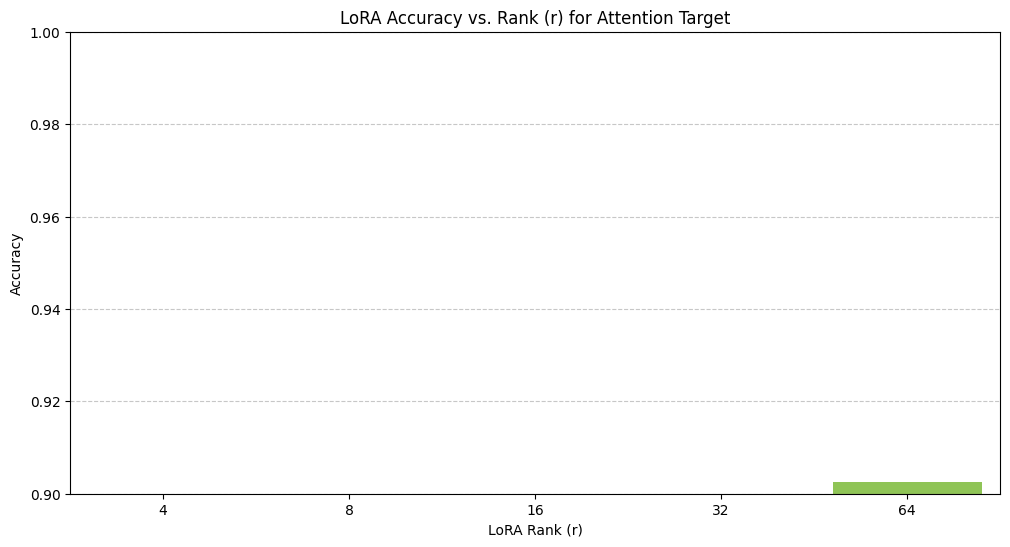

/tmp/ipykernel_771/2726814343.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='r', y='f1', data=lora_sweep_df, palette='viridis')


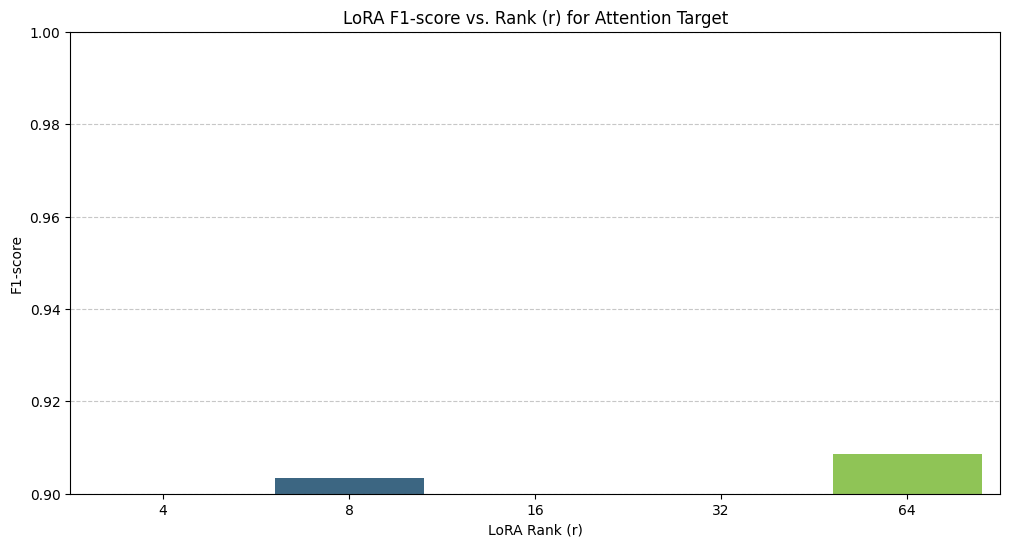

/tmp/ipykernel_771/2726814343.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='r', y='trainable_params', data=lora_sweep_df, palette='magma')


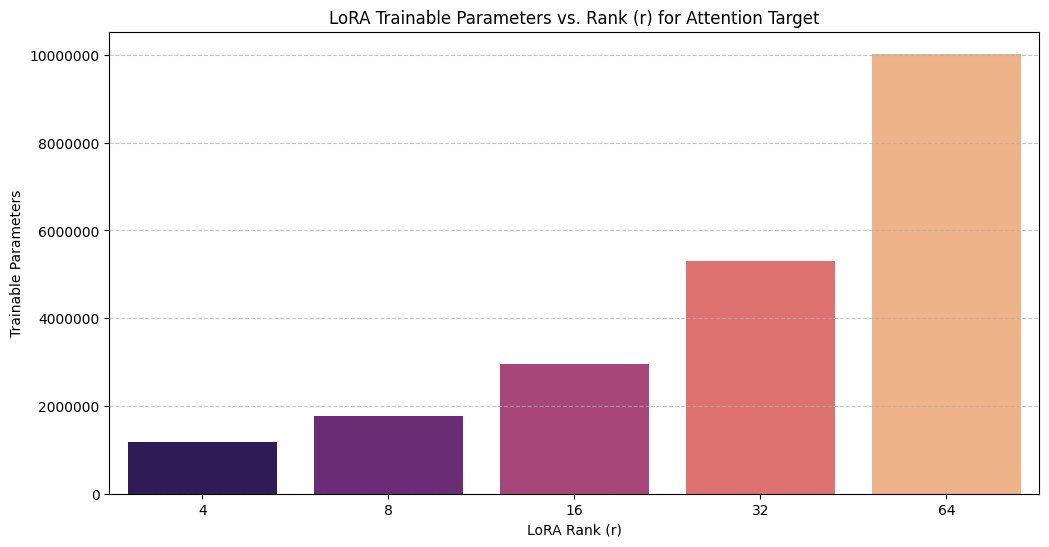

/tmp/ipykernel_771/2726814343.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='r', y='peak_memory_mb', data=lora_sweep_df, palette='magma')


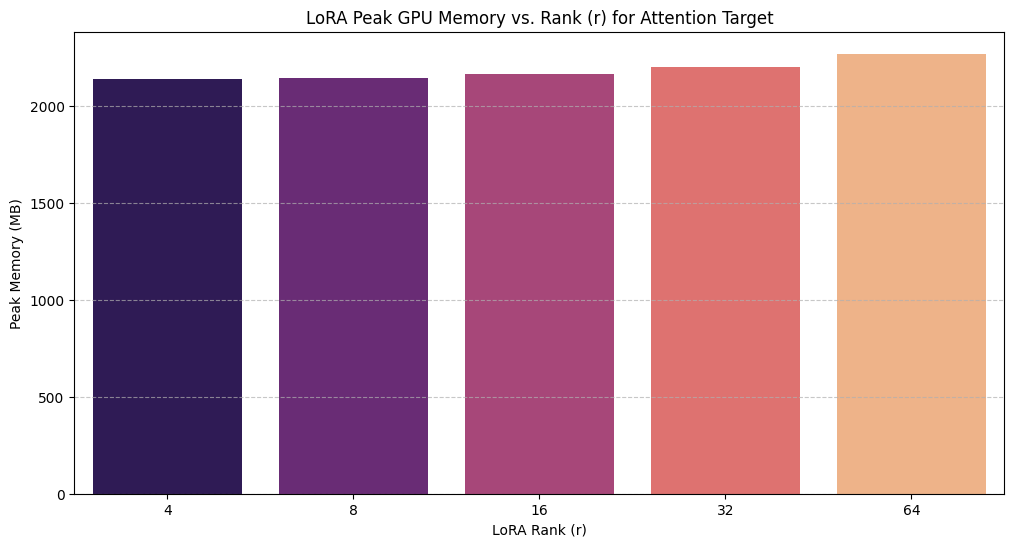

/tmp/ipykernel_771/2726814343.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='r', y='train_time_sec', data=lora_sweep_df, palette='magma')


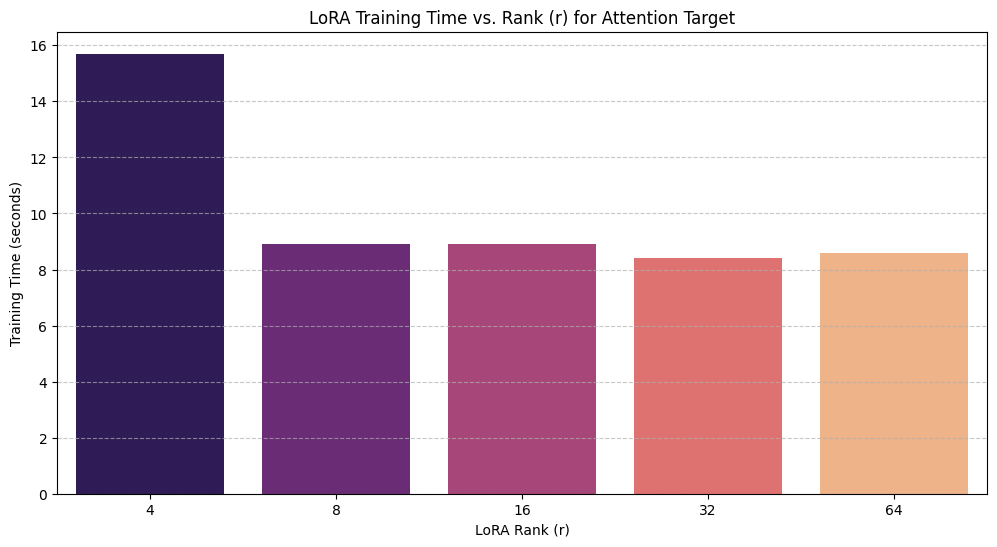

In [ ]:
# Filter the DataFrame for the LoRA attention sweep results
lora_sweep_df = df[df['experiment'].str.startswith('lora_attention_r')].copy()

# Extract 'r' from the experiment name
lora_sweep_df['r'] = lora_sweep_df['experiment'].str.extract(r'_r(\d+)').astype(int)

lora_sweep_df = lora_sweep_df.sort_values('r')

# Plotting Accuracy vs. Rank (r)
plt.figure(figsize=(12, 6))
sns.barplot(x='r', y='accuracy', data=lora_sweep_df, palette='viridis')
plt.title('LoRA Accuracy vs. Rank (r) for Attention Target')
plt.xlabel('LoRA Rank (r)')
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0.9, 1.0) # Set y-axis limit for better visualization
plt.show()

# Plotting F1-score vs. Rank (r)
plt.figure(figsize=(12, 6))
sns.barplot(x='r', y='f1', data=lora_sweep_df, palette='viridis')
plt.title('LoRA F1-score vs. Rank (r) for Attention Target')
plt.xlabel('LoRA Rank (r)')
plt.ylabel('F1-score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0.9, 1.0) # Set y-axis limit for better visualization
plt.show()

# Plotting Trainable Parameters vs. Rank (r)
plt.figure(figsize=(12, 6))
sns.barplot(x='r', y='trainable_params', data=lora_sweep_df, palette='magma')
plt.title('LoRA Trainable Parameters vs. Rank (r) for Attention Target')
plt.xlabel('LoRA Rank (r)')
plt.ylabel('Trainable Parameters')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation
plt.show()

# Plotting Peak GPU Memory vs. Rank (r)
plt.figure(figsize=(12, 6))
sns.barplot(x='r', y='peak_memory_mb', data=lora_sweep_df, palette='magma')
plt.title('LoRA Peak GPU Memory vs. Rank (r) for Attention Target')
plt.xlabel('LoRA Rank (r)')
plt.ylabel('Peak Memory (MB)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plotting Training Time vs. Rank (r)
plt.figure(figsize=(12, 6))
sns.barplot(x='r', y='train_time_sec', data=lora_sweep_df, palette='magma')
plt.title('LoRA Training Time vs. Rank (r) for Attention Target')
plt.xlabel('LoRA Rank (r)')
plt.ylabel('Training Time (seconds)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()




### Visualizing Ablation Results vs. Baseline

/tmp/ipykernel_771/388501140.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='experiment_label', y='accuracy', data=comparison_df, ax=axes[0], palette='viridis')
/tmp/ipykernel_771/388501140.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='experiment_label', y='f1', data=comparison_df, ax=axes[1], palette='viridis')


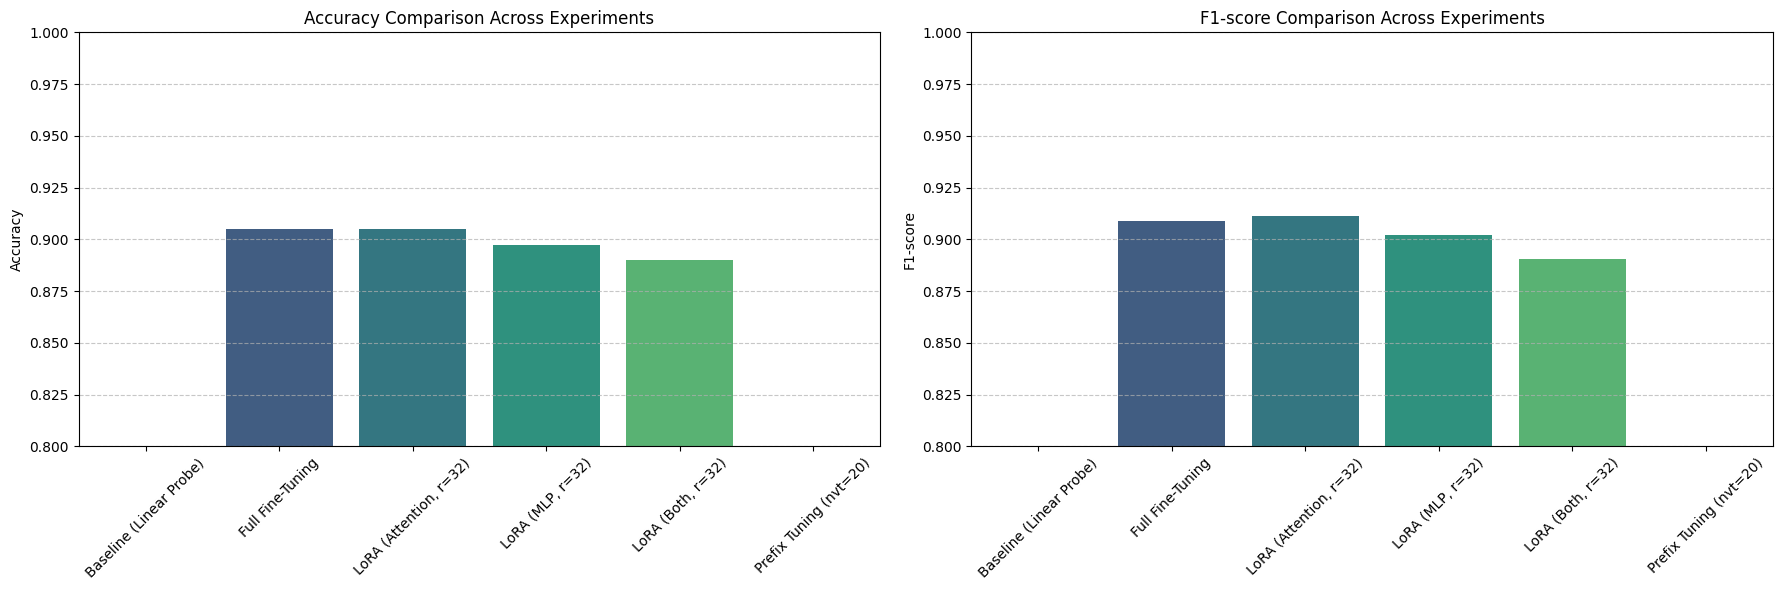

/tmp/ipykernel_771/388501140.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='experiment_label', y='trainable_params', data=comparison_df, ax=axes[0], palette='magma')
/tmp/ipykernel_771/388501140.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='experiment_label', y='peak_memory_mb', data=comparison_df, ax=axes[1], palette='magma')
/tmp/ipykernel_771/388501140.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='experiment_label', y='train_time_sec', data=comparison_df, ax=axes[2], palette='magma')


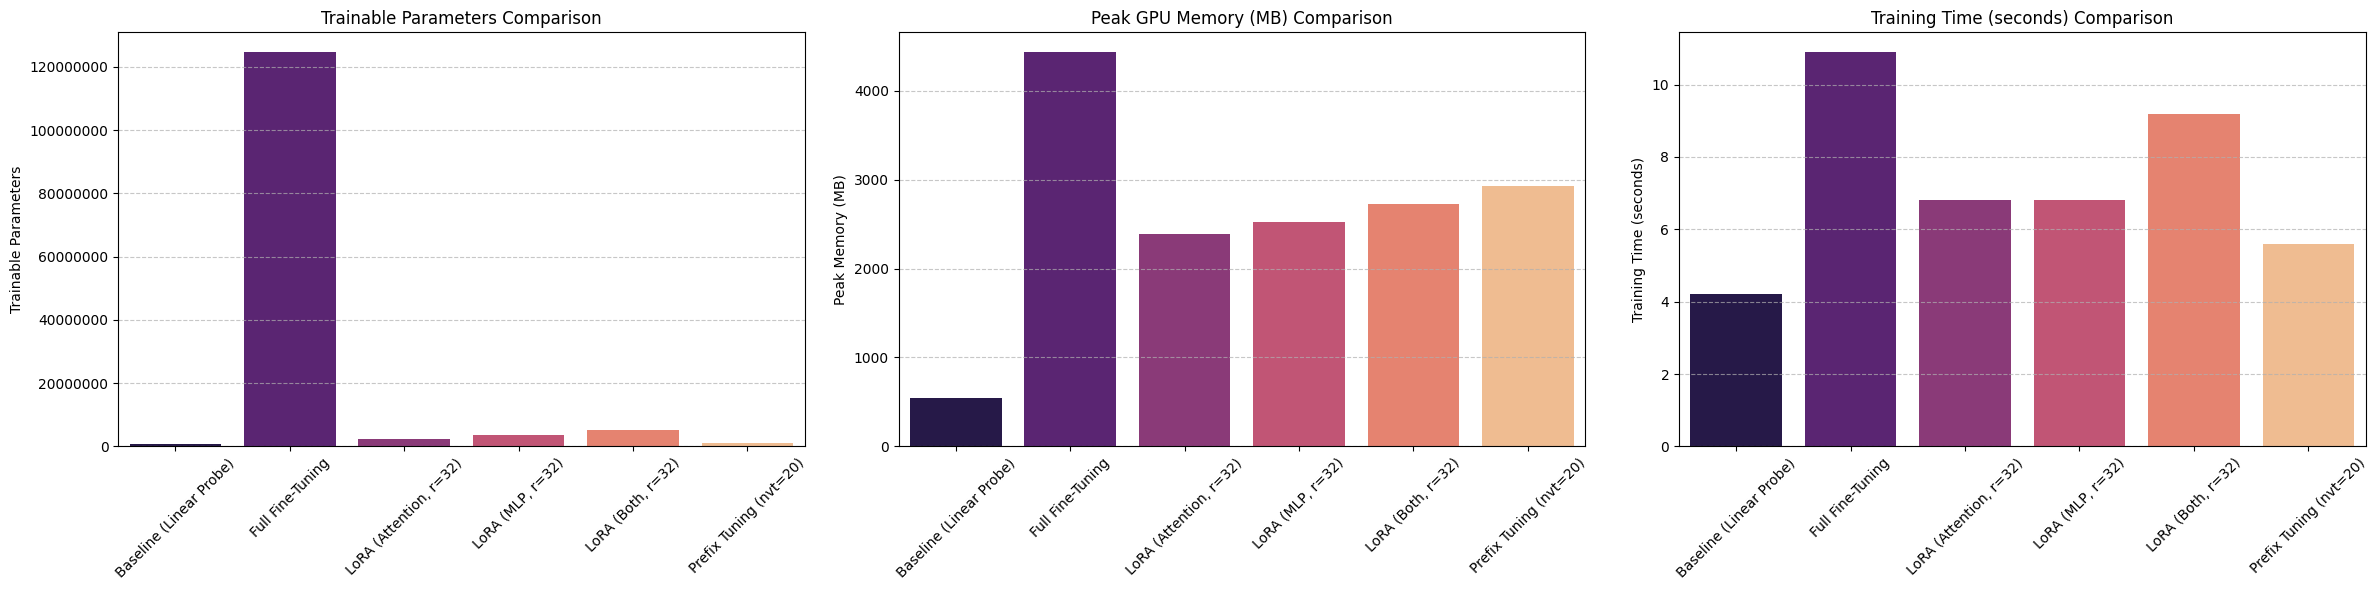

In [ ]:
# Get r and alpha from the variables defined in the ablation
current_ablation_r = ablation_r
current_ablation_alpha = 2*ablation_r # Assuming alpha is 2*r for ablation

# Plot Performance Metrics (Accuracy and F1)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x='experiment_label', y='accuracy', data=comparison_df, ax=axes[0], palette='viridis')
axes[0].set_title('Accuracy Comparison Across Experiments')
axes[0].set_xlabel('')
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].set_ylim(0.8, 1.0) # Set y-axis limit for better visualization

sns.barplot(x='experiment_label', y='f1', data=comparison_df, ax=axes[1], palette='viridis')
axes[1].set_title('F1-score Comparison Across Experiments')
axes[1].set_xlabel('')
axes[1].set_ylabel('F1-score')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].set_ylim(0.8, 1.0) # Set y-axis limit for better visualization

plt.tight_layout()
plt.show()

# Plot Efficiency Metrics (Trainable Params, Peak Memory, and Training Time)
fig, axes = plt.subplots(1, 3, figsize=(24, 6)) # Changed from (1, 2) to (1, 3) and adjusted figsize

sns.barplot(x='experiment_label', y='trainable_params', data=comparison_df, ax=axes[0], palette='magma')
axes[0].set_title('Trainable Parameters Comparison')
axes[0].set_xlabel('')
axes[0].set_ylabel('Trainable Parameters')
axes[0].tick_params(axis='x', rotation=45)
axes[0].ticklabel_format(style='plain', axis='y') # Prevent scientific notation
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(x='experiment_label', y='peak_memory_mb', data=comparison_df, ax=axes[1], palette='magma')
axes[1].set_title('Peak GPU Memory (MB) Comparison')
axes[1].set_xlabel('')
axes[1].set_ylabel('Peak Memory (MB)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(x='experiment_label', y='train_time_sec', data=comparison_df, ax=axes[2], palette='magma')
axes[2].set_title('Training Time (seconds) Comparison')
axes[2].set_xlabel('')
axes[2].set_ylabel('Training Time (seconds)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Accuracy vs. Trainable Parameters Comparison

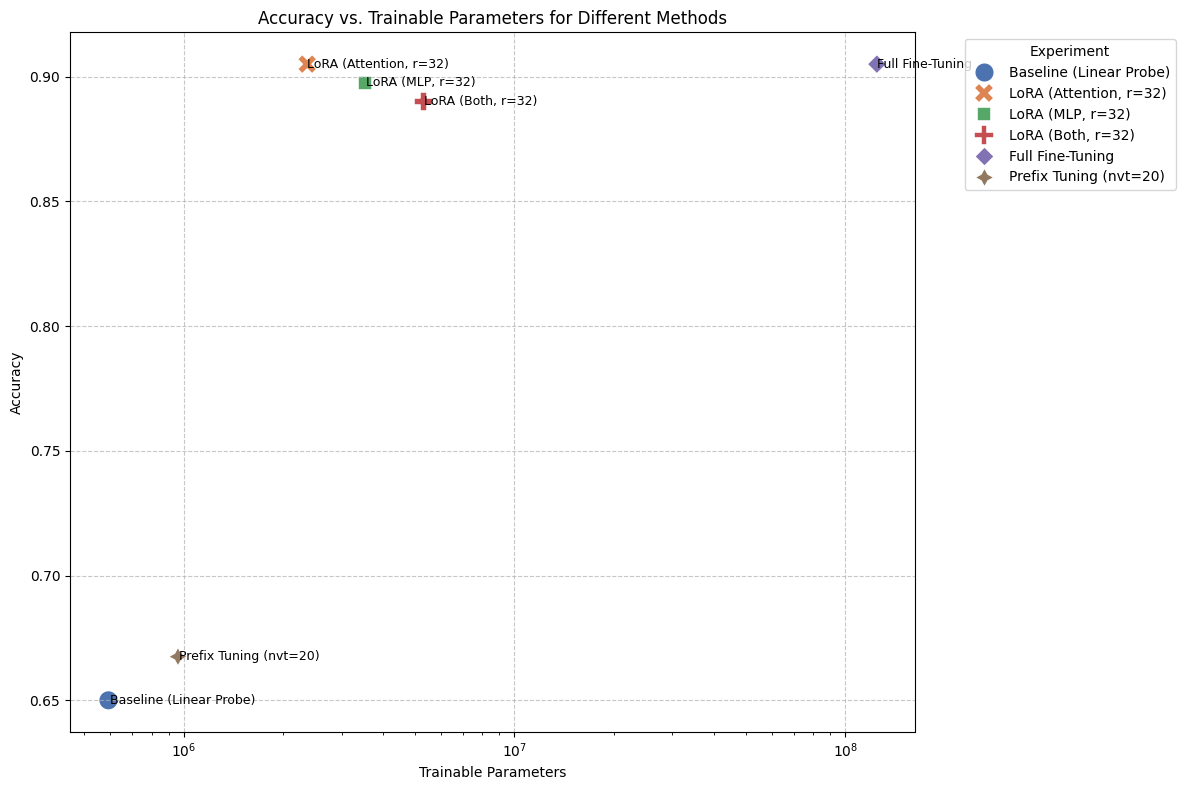

/tmp/ipykernel_771/3910097188.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


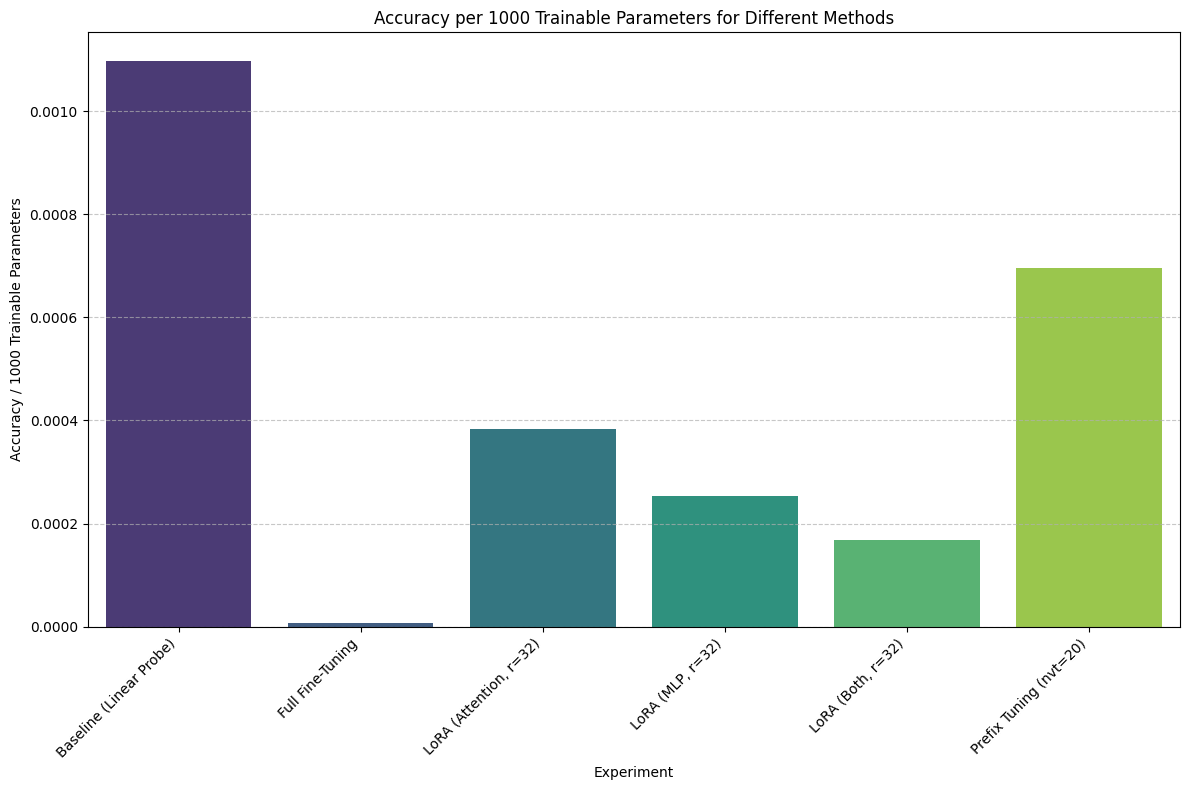

In [ ]:
# Define r and alpha from the kernel state for the LoRA 'both' experiment
current_ablation_r = ablation_r # From current kernel state: 32
current_ablation_alpha = ablation_alpha # From current kernel state: 64

# Plot: Accuracy vs. Trainable Parameters
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=comparison_df,
    x='trainable_params',
    y='accuracy',
    hue='experiment_label',
    s=200, # size of points
    style='experiment_label', # different markers for each experiment
    palette='deep'
)

for i, row in comparison_df.iterrows():
    plt.text(row['trainable_params'] + 5000, row['accuracy'], row['experiment_label'], fontsize=9, ha='left', va='center')

plt.title('Accuracy vs. Trainable Parameters for Different Methods')
plt.xlabel('Trainable Parameters')
plt.ylabel('Accuracy')
plt.xscale('log') # Use log scale for trainable parameters if they vary widely
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Experiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- New Plot: Accuracy per Trainable Parameters ---

# Calculate accuracy per trainable parameter
# To avoid division by zero for models with 0 trainable parameters (if any, e.g., during full freeze)
# Also, scale for better readability, e.g., per 1000 parameters
comparison_df['accuracy_per_k_params'] = comparison_df['accuracy'] / (comparison_df['trainable_params'] / 1000)

# Define order for the categorical labels on the plots
plot_category_order = [
    "Baseline (Linear Probe)",
    "Full Fine-Tuning",
    f"LoRA (Attention, r={current_ablation_r})",
    f"LoRA (MLP, r={current_ablation_r})",
    f"LoRA (Both, r={current_ablation_r})",
    "Prefix Tuning (nvt=20)"
]

# Reorder the DataFrame for consistent plotting
comparison_df['experiment_label'] = pd.Categorical(comparison_df['experiment_label'], categories=plot_category_order, ordered=True)
comparison_df = comparison_df.sort_values('experiment_label')

# Plot: Accuracy per Trainable Parameter
plt.figure(figsize=(12, 8))
sns.barplot(
    data=comparison_df,
    x='experiment_label',
    y='accuracy_per_k_params',
    palette='viridis'
)

plt.title('Accuracy per 1000 Trainable Parameters for Different Methods')
plt.xlabel('Experiment')
plt.ylabel('Accuracy / 1000 Trainable Parameters')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Accuracy per Trainable Parameters Comparison

/tmp/ipykernel_771/3616729280.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


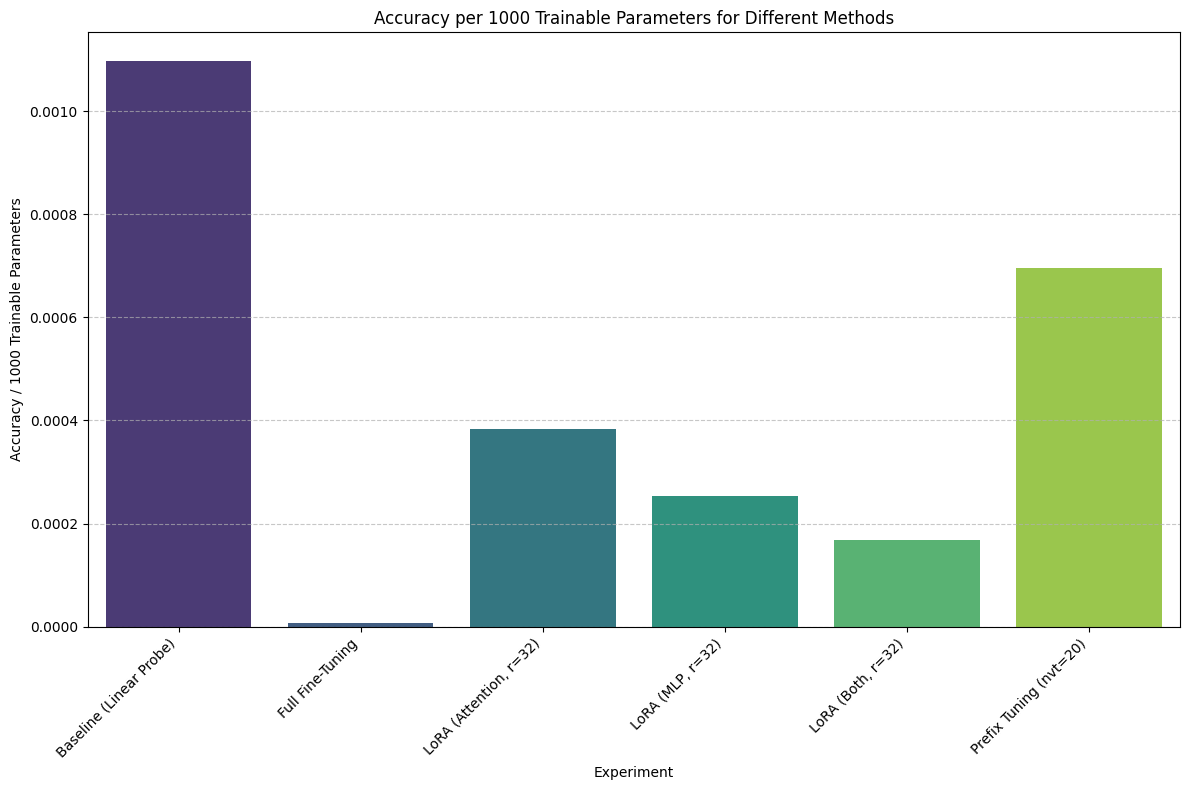

In [ ]:
# Define r and alpha from the kernel state for the LoRA 'both' experiment
current_ablation_r = ablation_r # From current kernel state
current_ablation_alpha = ablation_alpha # From current kernel state

# Calculate accuracy per trainable parameter
# To avoid division by zero for models with 0 trainable parameters (if any, e.g., during full freeze)
# Also, scale for better readability, e.g., per 1000 parameters
comparison_df['accuracy_per_k_params'] = comparison_df['accuracy'] / (comparison_df['trainable_params'] / 1000)

# Define order for the categorical labels on the plots
plot_category_order = [
    "Baseline (Linear Probe)",
    "Full Fine-Tuning",
    f"LoRA (Attention, r={current_ablation_r})",
    f"LoRA (MLP, r={current_ablation_r})",
    f"LoRA (Both, r={current_ablation_r})",
    "Prefix Tuning (nvt=20)"
]

# Reorder the DataFrame for consistent plotting
comparison_df['experiment_label'] = pd.Categorical(comparison_df['experiment_label'], categories=plot_category_order, ordered=True)
comparison_df = comparison_df.sort_values('experiment_label')

# Plot: Accuracy per Trainable Parameter
plt.figure(figsize=(12, 8))
sns.barplot(
    data=comparison_df,
    x='experiment_label',
    y='accuracy_per_k_params',
    palette='viridis'
)

plt.title('Accuracy per 1000 Trainable Parameters for Different Methods')
plt.xlabel('Experiment')
plt.ylabel('Accuracy / 1000 Trainable Parameters')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Next steps

- **Upper bound:** add full fine-tuning with `run_experiment("full_ft", build_base_model(), lr=2e-5)`.
- **Target-module ablation:** loop `build_lora_model(target=t)` for `t` in `"attention"`, `"mlp"`, `"both"`.
- **Rank / alpha sweep:** loop `build_lora_model(target="attention", r=r, alpha=2*r)` for `r` in `4, 8, 16, 32 and 64`.
- **Second PEFT method:** swap `LoraConfig` for an Adapter / prefix-tuning config from PEFT; the same `run_experiment` records it in the same table.


